# CycleGAN: Sketch ↔ Photo Domain Adaptation
**Course:** Generative AI (AI4009) | **Assignment:** No. 3 — Question 3 | **Semester:** Spring 2026

---
# 1. ENVIRONMENT SETUP

In [ ]:
!pip install -q gradio torchmetrics scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.5 MB/s eta 0:00:00


In [ ]:
import os, random, itertools
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: Tesla T4


In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 4
EPOCHS      = 15
LR          = 0.0002
BETAS       = (0.5, 0.999)
LAMBDA_CYC  = 10.0   # cycle consistency weight
LAMBDA_ID   = 5.0    # identity loss weight
N_RES       = 6      # ResNet blocks in generator
N_SAMPLES   = 2000   # images per domain

DATA_DIR = Path('./cyclegan_data')
CKPT_DIR = Path('./checkpoints')
for d in [DATA_DIR/'trainA', DATA_DIR/'trainB', DATA_DIR/'testA', DATA_DIR/'testB', CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Config ready')

Config ready


---
# 2. DATA PREPARATION
## Domain A — Sketches (QuickDraw .npy)

In [ ]:
import urllib.request

CATEGORIES = ['cat', 'dog', 'car', 'house', 'face']
BASE_URL   = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'
NPY_DIR    = Path('./quickdraw_npy')
NPY_DIR.mkdir(exist_ok=True)

for cat in CATEGORIES:
    npy_path = NPY_DIR / f'{cat}.npy'
    if not npy_path.exists():
        print(f'Downloading {cat}...')
        urllib.request.urlretrieve(f'{BASE_URL}{cat}.npy', npy_path)
    print(f'{cat} ready')

cat ready
dog ready
car ready
house ready
face ready


In [ ]:
# Convert .npy bitmap arrays → RGB PNG files (128×128)
def save_quickdraw(npy_dir, out_dir, n_per_cat, img_size=128):
    saved = 0
    for npy_path in sorted(npy_dir.glob('*.npy')):
        data = np.load(npy_path)  # (N, 784) uint8
        for i, row in enumerate(data[:n_per_cat]):
            img = Image.fromarray(row.reshape(28, 28)).resize((img_size, img_size), Image.LANCZOS)
            img = Image.merge('RGB', [img, img, img])  # grayscale → RGB
            img.save(out_dir / f'{npy_path.stem}_{i:04d}.png')
            saved += 1
    return saved

n_per_cat = N_SAMPLES // len(CATEGORIES)
train_cut = int(n_per_cat * 0.8)

# Temporarily save all to a temp dir, then split
tmp_dir = Path('./quickdraw_tmp'); tmp_dir.mkdir(exist_ok=True)
total   = save_quickdraw(NPY_DIR, tmp_dir, n_per_cat)

all_files = sorted(tmp_dir.glob('*.png'))
random.shuffle(all_files)
split     = int(len(all_files) * 0.8)

for f in all_files[:split]:
    f.rename(DATA_DIR / 'trainA' / f.name)
for f in all_files[split:]:
    f.rename(DATA_DIR / 'testA' / f.name)

print(f'Domain A — Train: {len(list((DATA_DIR/"trainA").iterdir()))}  Test: {len(list((DATA_DIR/"testA").iterdir()))}')

Domain A — Train: 1600  Test: 400


## Domain B — Photos (Kaggle: Sketchy Dataset)

In [ ]:
import kagglehub

# Download Sketchy dataset — contains both sketches and reference photos
sketchy_path = kagglehub.dataset_download('sharanyasundar/sketchy-dataset')
print('Sketchy dataset path:', sketchy_path)

Using Colab cache for faster access to the 'sketchy-dataset' dataset.
Sketchy dataset path: /kaggle/input/sketchy-dataset


In [ ]:
# Collect photo images from Sketchy dataset
# The Sketchy dataset has a 'photo' subfolder with real photos per category
EXTS = {'.jpg', '.jpeg', '.png'}

photo_files = []
# Walk all subdirectories and collect images
for root, dirs, files in os.walk(sketchy_path):
    for f in files:
        if Path(f).suffix.lower() in EXTS:
            full = Path(root) / f
            # Skip very small images (icons/thumbnails)
            try:
                img = Image.open(full)
                if img.size[0] >= 32 and img.size[1] >= 32:
                    photo_files.append(full)
            except:
                pass

# If Sketchy dataset doesn't have enough photos, also download animals dataset
if len(photo_files) < 200:
    print(f'Sketchy gave only {len(photo_files)} images, downloading animal photos...')
    animals_path = kagglehub.dataset_download('iamsouravbanerjee/animal-image-dataset-90-different-animals')
    for root, _, files in os.walk(animals_path):
        for f in files:
            if Path(f).suffix.lower() in EXTS:
                photo_files.append(Path(root) / f)

random.shuffle(photo_files)
photo_files = photo_files[:N_SAMPLES]
split       = int(len(photo_files) * 0.8)

for i, src in enumerate(photo_files[:split]):
    img = Image.open(src).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    img.save(DATA_DIR / 'trainB' / f'photo_{i:04d}.png')

for i, src in enumerate(photo_files[split:]):
    img = Image.open(src).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    img.save(DATA_DIR / 'testB' / f'photo_{i:04d}.png')

print(f"Domain B — Train: {len(list((DATA_DIR/'trainB').iterdir()))}  Test: {len(list((DATA_DIR/'testB').iterdir()))}")


Sketchy gave only 13 images, downloading animal photos...


100%|██████████| 656M/656M [00:04<00:00, 143MB/s]

Extracting files...


Domain B — Train: 1600  Test: 400


## Dataset & DataLoader

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16), transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


class UnpairedDataset(Dataset):
    EXTS = {'.png', '.jpg', '.jpeg'}

    def __init__(self, dir_A, dir_B, transform=None):
        self.files_A   = sorted([f for f in Path(dir_A).iterdir() if f.suffix.lower() in self.EXTS])
        self.files_B   = sorted([f for f in Path(dir_B).iterdir() if f.suffix.lower() in self.EXTS])
        self.transform = transform

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        return self.transform(img) if self.transform else img

    def __getitem__(self, idx):
        a = self._load(self.files_A[idx % len(self.files_A)])
        b = self._load(self.files_B[random.randint(0, len(self.files_B)-1)])
        return {'A': a, 'B': b}


train_ds = UnpairedDataset(DATA_DIR/'trainA', DATA_DIR/'trainB', train_transform)
test_ds  = UnpairedDataset(DATA_DIR/'testA',  DATA_DIR/'testB',  test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Test: {len(test_ds)} | Batches/epoch: {len(train_loader)}')

Train: 1600 | Test: 400 | Batches/epoch: 400


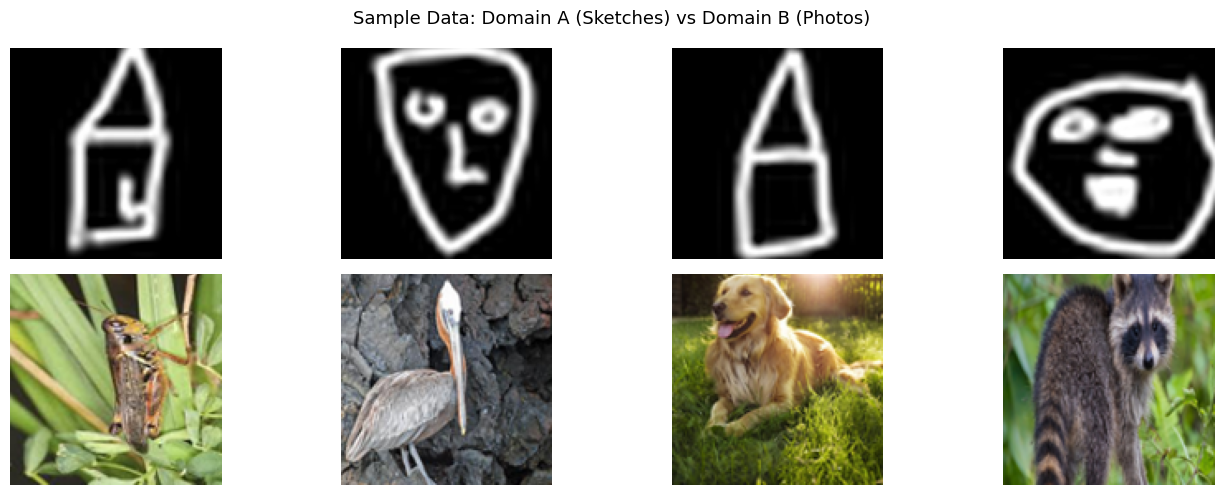

In [ ]:
# Visualise sample data
batch = next(iter(train_loader))
fig, axes = plt.subplots(2, BATCH_SIZE, figsize=(14, 5))
fig.suptitle('Sample Data: Domain A (Sketches) vs Domain B (Photos)', fontsize=13)
for j in range(BATCH_SIZE):
    for row, key, lbl in [(0, 'A', 'Sketch'), (1, 'B', 'Photo')]:
        img = batch[key][j].permute(1,2,0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        axes[row, j].imshow(img)
        axes[row, j].axis('off')
        if j == 0: axes[row, j].set_ylabel(lbl, fontsize=10)
plt.tight_layout(); plt.show()

---
# 3. MODEL ARCHITECTURE
## ResNet Generator

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3, bias=False),
            nn.InstanceNorm2d(dim), nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3, bias=False),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.block(x)


class ResNetGenerator(nn.Module):
    """image (3,128,128) → image (3,128,128)"""
    def __init__(self, n_res=N_RES):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, 7, bias=False), nn.InstanceNorm2d(64), nn.ReLU(True),
            # Downsample
            nn.Conv2d(64,  128, 3, stride=2, padding=1, bias=False), nn.InstanceNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False), nn.InstanceNorm2d(256), nn.ReLU(True),
        ]
        # ResNet blocks
        layers += [ResBlock(256) for _ in range(n_res)]
        # Upsample
        layers += [
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(64),  nn.ReLU(True),
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, 7),
            nn.Tanh()
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## PatchGAN Discriminator

In [ ]:
class PatchDiscriminator(nn.Module):
    """70×70 PatchGAN discriminator."""
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1, bias=False)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, True))
            return layers

        self.net = nn.Sequential(
            *block(3,   64,  norm=False),
            *block(64,  128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, x):
        return self.net(x)

## Initialise Models

In [ ]:
def weights_init(m):
    if 'Conv' in m.__class__.__name__:
        nn.init.normal_(m.weight, 0.0, 0.02)


# Generators
G_AB = ResNetGenerator().to(device).apply(weights_init)   # Sketch → Photo
G_BA = ResNetGenerator().to(device).apply(weights_init)   # Photo  → Sketch

# Discriminators
D_A  = PatchDiscriminator().to(device).apply(weights_init)  # classifies sketches
D_B  = PatchDiscriminator().to(device).apply(weights_init)  # classifies photos

# Dual GPU support
if torch.cuda.device_count() > 1:
    G_AB = nn.DataParallel(G_AB)
    G_BA = nn.DataParallel(G_BA)
    D_A  = nn.DataParallel(D_A)
    D_B  = nn.DataParallel(D_B)
    print(f'Using {torch.cuda.device_count()} GPUs')

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f'Generator params   : {count_params(G_AB):,}')
print(f'Discriminator params: {count_params(D_A):,}')

Generator params   : 7,833,987
Discriminator params: 2,763,777


---
# 4. TRAINING SETUP

In [ ]:
# Loss functions
criterion_adv = nn.MSELoss()   # LSGAN adversarial loss
criterion_cyc = nn.L1Loss()    # cycle consistency
criterion_id  = nn.L1Loss()    # identity

# Optimizers — generators share one optimizer, discriminators share another
opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=BETAS)
opt_D = torch.optim.Adam(itertools.chain(D_A.parameters(),  D_B.parameters()),  lr=LR, betas=BETAS)

scaler = torch.amp.GradScaler('cuda')

# Fixed test batch for consistent visualisation
test_batch  = next(iter(test_loader))
fixed_A     = test_batch['A'][:5].to(device)
fixed_B     = test_batch['B'][:5].to(device)

## Training Loop

In [ ]:
G_losses, D_losses, Cyc_losses = [], [], []

for epoch in range(1, EPOCHS + 1):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
    g_ep, d_ep, cyc_ep = 0.0, 0.0, 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        real_A = batch['A'].to(device, non_blocking=True)
        real_B = batch['B'].to(device, non_blocking=True)

        # Target tensors for LSGAN (patch-level)
        real_label = torch.ones(real_A.size(0), 1, 7, 7, device=device)
        fake_label = torch.zeros(real_A.size(0), 1, 7, 7, device=device)

        # ── GENERATORS ───────────────────────────────────────────────────
        opt_G.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_B  = G_AB(real_A)           # Sketch → Photo
            fake_A  = G_BA(real_B)           # Photo  → Sketch
            recon_A = G_BA(fake_B)           # Photo  → Sketch (cycle)
            recon_B = G_AB(fake_A)           # Sketch → Photo  (cycle)
            id_A    = G_BA(real_A)           # identity: Sketch → Sketch
            id_B    = G_AB(real_B)           # identity: Photo  → Photo

            # Adversarial
            loss_adv = (criterion_adv(D_B(fake_B), real_label) +
                        criterion_adv(D_A(fake_A), real_label))
            # Cycle
            loss_cyc = LAMBDA_CYC * (criterion_cyc(recon_A, real_A) +
                                     criterion_cyc(recon_B, real_B))
            # Identity
            loss_id  = LAMBDA_ID  * (criterion_id(id_A, real_A) +
                                     criterion_id(id_B, real_B))
            loss_G   = loss_adv + loss_cyc + loss_id

        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        scaler.update()

        # ── DISCRIMINATORS ────────────────────────────────────────────────
        opt_D.zero_grad()
        with torch.amp.autocast('cuda'):
            loss_D = (criterion_adv(D_A(real_A), real_label) +
                      criterion_adv(D_A(fake_A.detach()), fake_label) +
                      criterion_adv(D_B(real_B), real_label) +
                      criterion_adv(D_B(fake_B.detach()), fake_label)) * 0.5

        scaler.scale(loss_D).backward()
        scaler.step(opt_D)
        scaler.update()

        g_ep   += loss_G.item()
        d_ep   += loss_D.item()
        cyc_ep += loss_cyc.item()

    n = len(train_loader)
    G_losses.append(g_ep/n); D_losses.append(d_ep/n); Cyc_losses.append(cyc_ep/n)
    print(f'Epoch {epoch}/{EPOCHS}  G={g_ep/n:.4f}  D={d_ep/n:.4f}  Cyc={cyc_ep/n:.4f}')

    # Save checkpoint every 5 epochs
    if epoch % 5 == 0:
        torch.save(G_AB.state_dict(), CKPT_DIR/f'G_AB_ep{epoch}.pt')
        torch.save(G_BA.state_dict(), CKPT_DIR/f'G_BA_ep{epoch}.pt')

print('Training complete!')

Epoch 1/15: 100%|██████████| 400/400 [01:12<00:00,  5.49it/s]


Epoch 1/15  G=7.7257  D=0.6595  Cyc=4.4482


Epoch 2/15: 100%|██████████| 400/400 [01:03<00:00,  6.28it/s]


Epoch 2/15  G=6.1310  D=0.4056  Cyc=3.5730


Epoch 3/15: 100%|██████████| 400/400 [01:05<00:00,  6.12it/s]


...

Epoch 13/15  G=4.9883  D=0.3119  Cyc=2.7574


Epoch 14/15: 100%|██████████| 400/400 [01:07<00:00,  5.95it/s]


Epoch 14/15  G=4.9952  D=0.2910  Cyc=2.7431


Epoch 15/15: 100%|██████████| 400/400 [01:07<00:00,  5.96it/s]


Epoch 15/15  G=5.0676  D=0.2852  Cyc=2.7888
Training complete!


---
# 5. TRAINING LOSS PLOTS

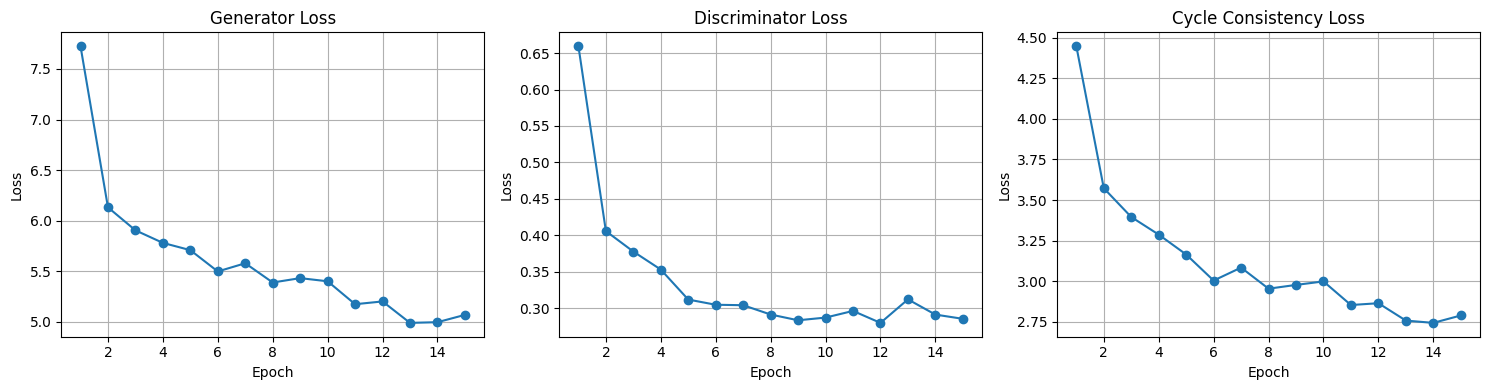

In [ ]:
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, vals, title in zip(axes,
    [G_losses, D_losses, Cyc_losses],
    ['Generator Loss', 'Discriminator Loss', 'Cycle Consistency Loss']):
    ax.plot(ep, vals, marker='o')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(True)

plt.tight_layout(); plt.show()

---
# 6. VISUALIZATION MODULE
Show: Input Sketch → Generated Photo → Reconstructed Sketch (and vice versa)

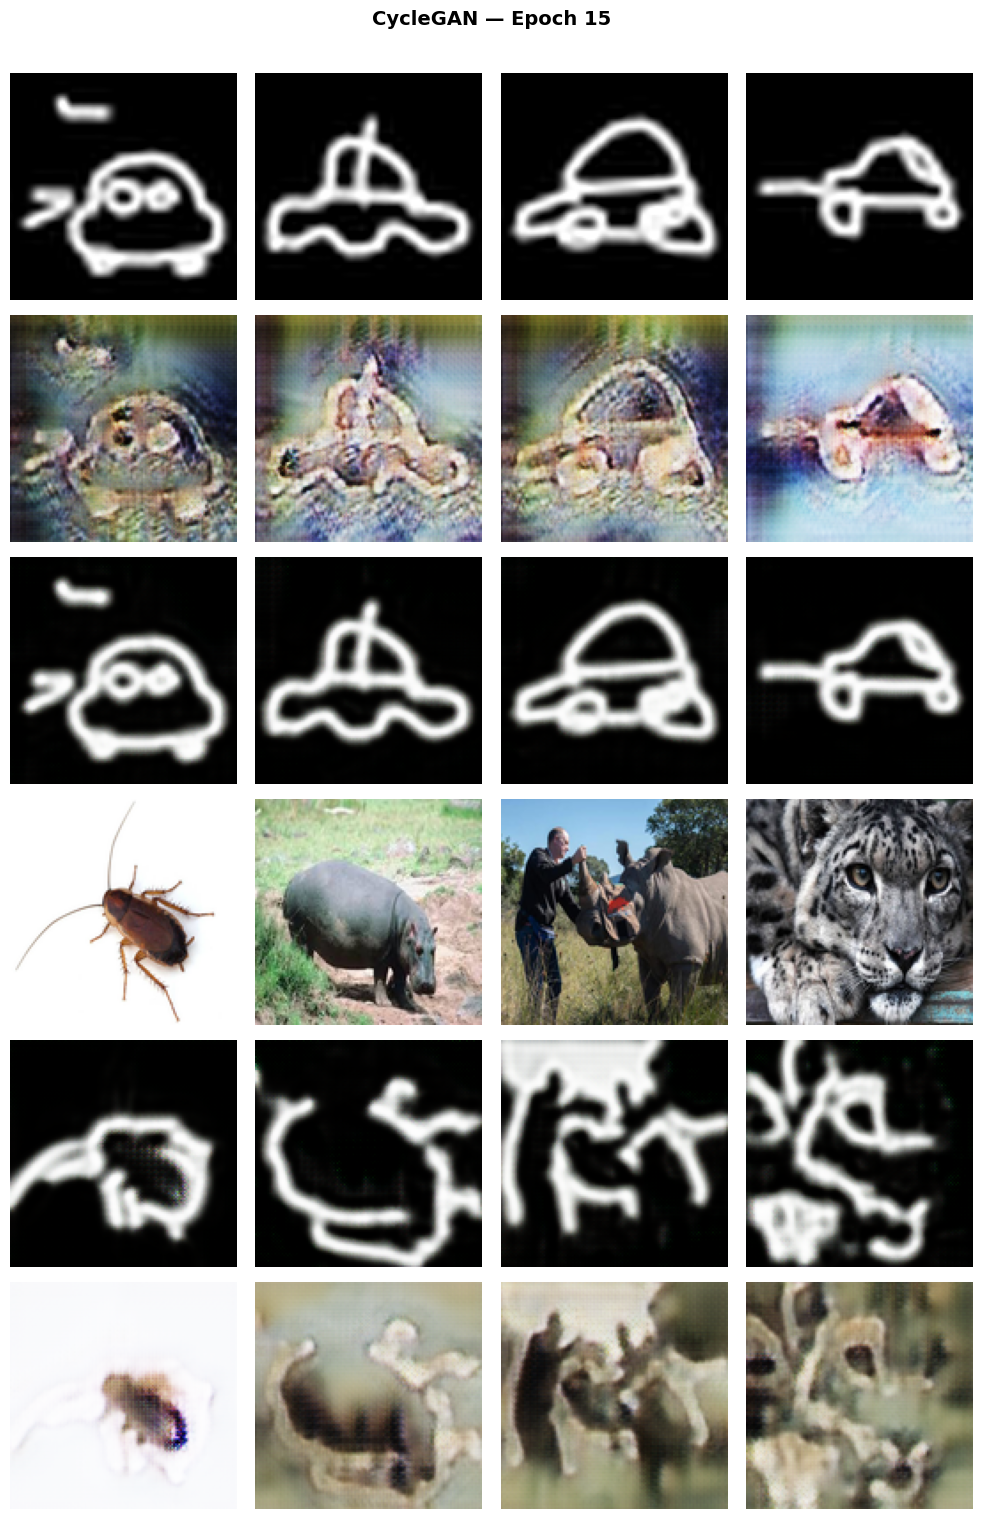

In [ ]:
def denorm(t):
    img = t.permute(1, 2, 0).cpu().float().numpy() * 0.5 + 0.5
    return img.clip(0, 1)


@torch.no_grad()
def show_translations(n=6, epoch=None):
    """
    Displays 6 rows x n columns matching the reference output:
    Row 1: Input Sketches
    Row 2: Sketch → Photo (G_AB)
    Row 3: Reconstructed Sketch (G_BA of fake_B)
    Row 4: Input Photos
    Row 5: Photo → Sketch (G_BA)
    Row 6: Reconstructed Photo (G_AB of fake_A)
    """
    G_AB.eval(); G_BA.eval()
    n = min(n, fixed_A.shape[0], fixed_B.shape[0])

    with torch.no_grad():
        fake_B  = G_AB(fixed_A[:n])   # Sketch → Photo
        recon_A = G_BA(fake_B)         # → back to Sketch
        fake_A  = G_BA(fixed_B[:n])   # Photo  → Sketch
        recon_B = G_AB(fake_A)         # → back to Photo

    row_data = [
        (fixed_A[:n],  'Input Sketch'),
        (fake_B,        'Sketch → Photo'),
        (recon_A,       'Reconstructed Sketch'),
        (fixed_B[:n],  'Input Photo'),
        (fake_A,        'Photo → Sketch'),
        (recon_B,       'Reconstructed Photo'),
    ]

    fig, axes = plt.subplots(6, n, figsize=(2.5*n, 15))
    title = f'CycleGAN — Epoch {epoch}' if epoch else 'CycleGAN — Final Results'
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for row_idx, (imgs, row_label) in enumerate(row_data):
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            ax.imshow(denorm(imgs[col_idx]))
            ax.axis('off')
        # Row label on the left of first column
        axes[row_idx, 0].set_ylabel(row_label, fontsize=9, rotation=90, labelpad=5)

    plt.tight_layout()
    plt.show()

show_translations(n=6, epoch=EPOCHS)


---
# 7. QUANTITATIVE EVALUATION (SSIM & PSNR)

In [ ]:
def to_numpy(tensor):
    return (tensor.permute(1,2,0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)


@torch.no_grad()
def evaluate_metrics(n=5):
    G_AB.eval(); G_BA.eval()
    ssim_ab, psnr_ab, ssim_ba, psnr_ba = [], [], [], []

    fake_B  = G_AB(fixed_A[:n])
    recon_A = G_BA(fake_B)
    fake_A  = G_BA(fixed_B[:n])
    recon_B = G_AB(fake_A)

    for i in range(n):
        orig_a = to_numpy(fixed_A[i])
        rec_a  = to_numpy(recon_A[i])
        orig_b = to_numpy(fixed_B[i])
        rec_b  = to_numpy(recon_B[i])

        ssim_ab.append(ssim_fn(orig_a, rec_a, channel_axis=2, data_range=1.0))
        psnr_ab.append(psnr_fn(orig_a, rec_a, data_range=1.0))
        ssim_ba.append(ssim_fn(orig_b, rec_b, channel_axis=2, data_range=1.0))
        psnr_ba.append(psnr_fn(orig_b, rec_b, data_range=1.0))

    print('=== Cycle Reconstruction Quality ===')
    print(f'Sketch  cycle — SSIM: {np.mean(ssim_ab):.4f}  PSNR: {np.mean(psnr_ab):.2f} dB')
    print(f'Photo   cycle — SSIM: {np.mean(psnr_ba):.4f}  PSNR: {np.mean(psnr_ba):.2f} dB')

evaluate_metrics(n=fixed_A.shape[0])

=== Cycle Reconstruction Quality ===
Sketch  cycle — SSIM: 0.8712  PSNR: 28.08 dB
Photo   cycle — SSIM: 17.4086  PSNR: 17.41 dB


---
# 8. SAVE FINAL MODELS

In [ ]:
torch.save(G_AB.state_dict(), CKPT_DIR/'G_AB_final.pt')
torch.save(G_BA.state_dict(), CKPT_DIR/'G_BA_final.pt')
torch.save(D_A.state_dict(),  CKPT_DIR/'D_A_final.pt')
torch.save(D_B.state_dict(),  CKPT_DIR/'D_B_final.pt')
print('Models saved!')

Models saved!


---
# 9. GRADIO APP

In [ ]:
import gradio as gr

G_AB.eval(); G_BA.eval()

infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


def to_pil(tensor):
    arr = ((tensor[0].permute(1,2,0).cpu().numpy() * 0.5 + 0.5) * 255).clip(0,255).astype(np.uint8)
    return Image.fromarray(arr)


@torch.no_grad()
def translate(pil_image, direction):
    """
    Returns 3 images: Input | Translated | Reconstructed
    """
    img = infer_transform(pil_image.convert('RGB')).unsqueeze(0).to(device)

    if direction == 'Sketch → Photo':
        translated  = G_AB(img)          # Sketch → Photo
        reconstructed = G_BA(translated)  # Photo  → Sketch (cycle)
    else:
        translated  = G_BA(img)          # Photo  → Sketch
        reconstructed = G_AB(translated)  # Sketch → Photo (cycle)

    return pil_image, to_pil(translated), to_pil(reconstructed)


with gr.Blocks(title='CycleGAN Demo') as demo:
    gr.Markdown('# CycleGAN — Sketch ↔ Photo Translation')
    gr.Markdown('Upload an image, choose translation direction. See Input → Translated → Reconstructed.')
    with gr.Row():
        inp_img = gr.Image(type='pil', label='Input Image')
        direction = gr.Radio(['Sketch → Photo', 'Photo → Sketch'], value='Sketch → Photo', label='Direction')
    btn = gr.Button('Translate', variant='primary')
    with gr.Row():
        out_input = gr.Image(type='pil', label='Input')
        out_trans = gr.Image(type='pil', label='Translated')
        out_recon = gr.Image(type='pil', label='Reconstructed (Cycle)')
    btn.click(translate, [inp_img, direction], [out_input, out_trans, out_recon])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84e1fa8e03835d6ac2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
